In [103]:
# simple hack to support import module from parent directory
import sys
sys.path.append('../src')


from collections import Counter
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [104]:
from rl4llm.utils import load_from_jsonl_file

In [105]:
sample_files = [
    "../runs/enhanced_grpo_qwen2.5_3b_math/samples/training_samples_rank0.jsonl.gz",
    "../runs/enhanced_grpo_qwen2.5_3b_math/samples/training_samples_rank1.jsonl.gz",
    "../runs/enhanced_grpo_qwen2.5_3b_math/samples/training_samples_rank2.jsonl.gz",
    "../runs/enhanced_grpo_qwen2.5_3b_math/samples/training_samples_rank3.jsonl.gz",
    # "../runs/enhanced_grpo_qwen2.5_1.5b_gsm8k/samples/training_samples_rank0.jsonl.gz",
    # "../runs/enhanced_grpo_qwen2.5_1.5b_gsm8k/samples/training_samples_rank1.jsonl.gz",
    # "../runs/enhanced_grpo_qwen2.5_1.5b_gsm8k/samples/training_samples_rank2.jsonl.gz",
    # "../runs/enhanced_grpo_qwen2.5_1.5b_gsm8k/samples/training_samples_rank3.jsonl.gz",
]

In [106]:
samples = []
for f in sample_files:
    samples.extend(load_from_jsonl_file(f))

print(f"Total samples: {len(samples)}")

Total samples: 3520


In [107]:
# Convert samples to pandas dataframe
df_samples = pd.DataFrame(samples)

In [108]:
display(df_samples.head())

,question,task_type,ground_truth,completion,accuracy_reward,format_reward,total_reward,completion_length,step
0,"Triangle $ABC$ has sides of length 5, 12 and 1...",MATH,\dfrac{1}{2},To find the ratio of the areas of triangle \(A...,1.0,0.0,1.0,568,0
1,"Triangle $ABC$ has sides of length 5, 12 and 1...",MATH,\dfrac{1}{2},To tackle the relative areas of triangles \(AB...,1.0,0.0,1.0,538,0
2,"Triangle $ABC$ has sides of length 5, 12 and 1...",MATH,\dfrac{1}{2},To find the region of the triangle $\Delta ABC...,1.0,0.0,1.0,481,0
3,"Triangle $ABC$ has sides of length 5, 12 and 1...",MATH,\dfrac{1}{2},Approach this problem by deriving the area sol...,1.0,0.0,1.0,560,0
4,"Triangle $ABC$ has sides of length 5, 12 and 1...",MATH,\dfrac{1}{2},Workings readily show that the triangles are r...,1.0,0.0,1.0,305,0


In [109]:
display(df_samples['step'].unique())

array([0, 1, 2, 3])

In [ ]:
display(df_samples['completion_length'].max())
display(df_samples['completion_length'].min())
display(df_samples['completion_length'].median())
display(df_samples['completion_length'].mean())

np.int64(2000)

np.int64(17)

np.float64(482.5)

np.float64(577.1661931818181)

## Plot First N words distributions

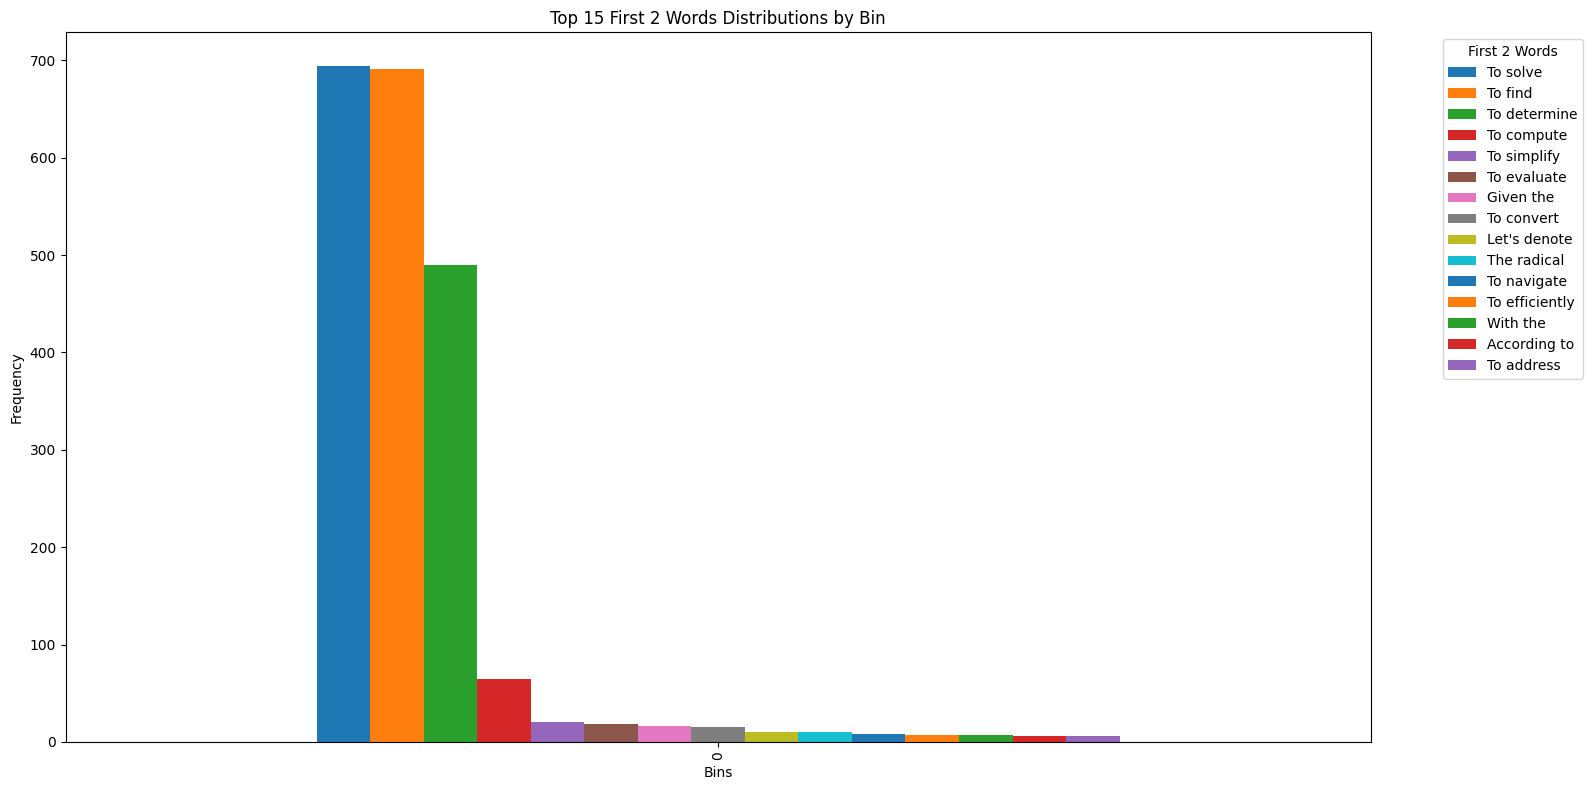

In [110]:

import re
import numpy as np

# Function to get the first N words from a text while preserving LaTeX math code
def get_first_n_words(text, n):
    """
    Extracts the first N words from a text while preserving LaTeX math code.

    Parameters:
        text (str): The input text.
        n (int): The number of words to extract.

    Returns:
        str: The first N words of the text.
    """
    # Regular expression to match LaTeX math code (e.g., $...$ or $$...$$)
    latex_pattern = r"(\$.*?\$|\\$$.*?\\$$)"

    # Split the text into words, treating LaTeX math code as a single "word"
    words = re.split(r'(\s+)', text)  # Split by whitespace but keep it in the result
    result = []
    word_count = 0

    for word in words:
        word = word.replace('$', '').replace('\\', '') # Remove $ and \
        if re.match(latex_pattern, word):
            result.append(word)
        elif word.strip():
            result.append(word)
            word_count += 1
        else:
            result.append(word)

        if word_count >= n:
            break

    return ''.join(result).strip()


# Function to bin data and plot grouped bar chart for top N first few words distributions
def plot_grouped_word_distributions_by_bins(df, step_column, bin_size, top_n, first_n_words):
    """
    Bins the data based on the step column, computes the top N first few words distributions for each bin,
    and plots the results in a grouped bar chart.

    Parameters:
        df (pd.DataFrame): The input DataFrame.
        step_column (str): The column name to bin the data on.
        bin_size (int): The size of each bin.
        top_n (int): The number of top word combinations to display.
        first_n_words (int): The number of first words to consider for combinations.
    """
    # Create a new column for the first N words
    df[f'first_{first_n_words}_words'] = df['completion'].apply(lambda x: get_first_n_words(x, first_n_words))

    # Compute the bin for each step value
    df['bin'] = (df[step_column] // bin_size) * bin_size

    # Group by bins and compute the frequency of each word combination
    grouped = df.groupby('bin')[f'first_{first_n_words}_words'].value_counts().unstack(fill_value=0)

    # Select the top N words across all bins
    top_words = grouped.sum(axis=0).nlargest(top_n).index

    # Filter the grouped data to include only the top N words
    grouped = grouped[top_words]

    # Plot the grouped bar chart
    ax = grouped.plot(kind='bar', figsize=(16, 8), width=0.8)
    plt.xlabel('Bins')
    plt.ylabel('Frequency')
    plt.title(f'Top {top_n} First {first_n_words} Words Distributions by Bin')
    plt.legend(title=f'First {first_n_words} Words', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    # Check and sanitize legend labels to prevent LaTeX parsing errors
    legend_labels = []
    for label in top_words:
        if isinstance(label, str) and label.startswith('$') and label.endswith('$'):
            legend_labels.append(label) # Keep valid latex labels if intended
        elif isinstance(label, str) and label.startswith('$'):
            legend_labels.append(r'\$' + label[1:]) # Escape leading $ if it's causing issues and not intended latex
        else:
            legend_labels.append(label)

    # Update legend labels - this part is crucial to apply the sanitized labels
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles, legend_labels, title=f'First {first_n_words} Words', bbox_to_anchor=(1.05, 1), loc='upper left')


    plt.show()

# Example usage
# Assuming df_samples is your DataFrame and it has a "text" column and a "step" column
bin_size = 20  # Configurable bin size (e.g., 0-10, 11-20, etc.)
top_n = 15  # Top N word combinations to display
first_n_words = 2  # Number of first words to consider

plot_grouped_word_distributions_by_bins(df_samples, step_column='step', bin_size=bin_size, top_n=top_n, first_n_words=first_n_words) 


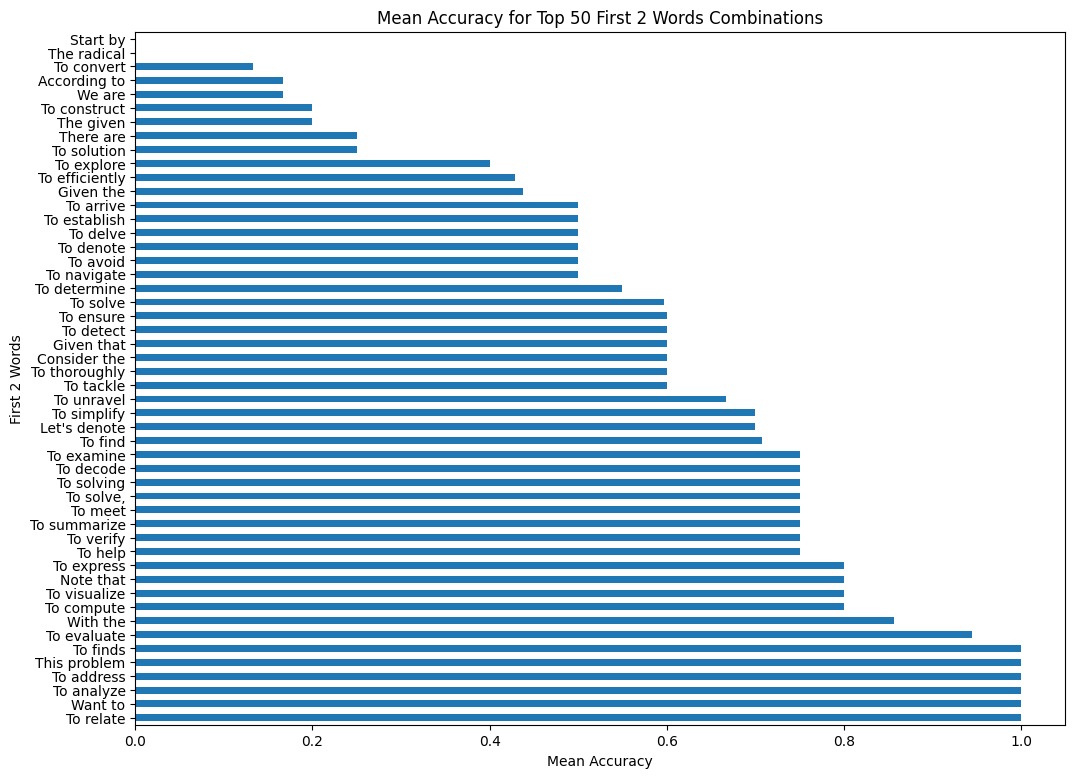

In [111]:
# Calculate the mean accuracy for each of the top 30 first 3 words
top_n = 50
top_n_first_2_words = df_samples['first_2_words'].value_counts().head(top_n).index
mean_accuracy = df_samples[df_samples['first_2_words'].isin(top_n_first_2_words)].groupby('first_2_words')['accuracy_reward'].mean()

# Plot the mean accuracy for the top 30 first 3 words
plt.figure(figsize=(12, 9))
mean_accuracy.sort_values().plot(kind='barh')
plt.xlabel('Mean Accuracy')
plt.ylabel('First 2 Words')
plt.title(f'Mean Accuracy for Top {top_n} First 2 Words Combinations')
plt.gca().invert_yaxis()
plt.show()

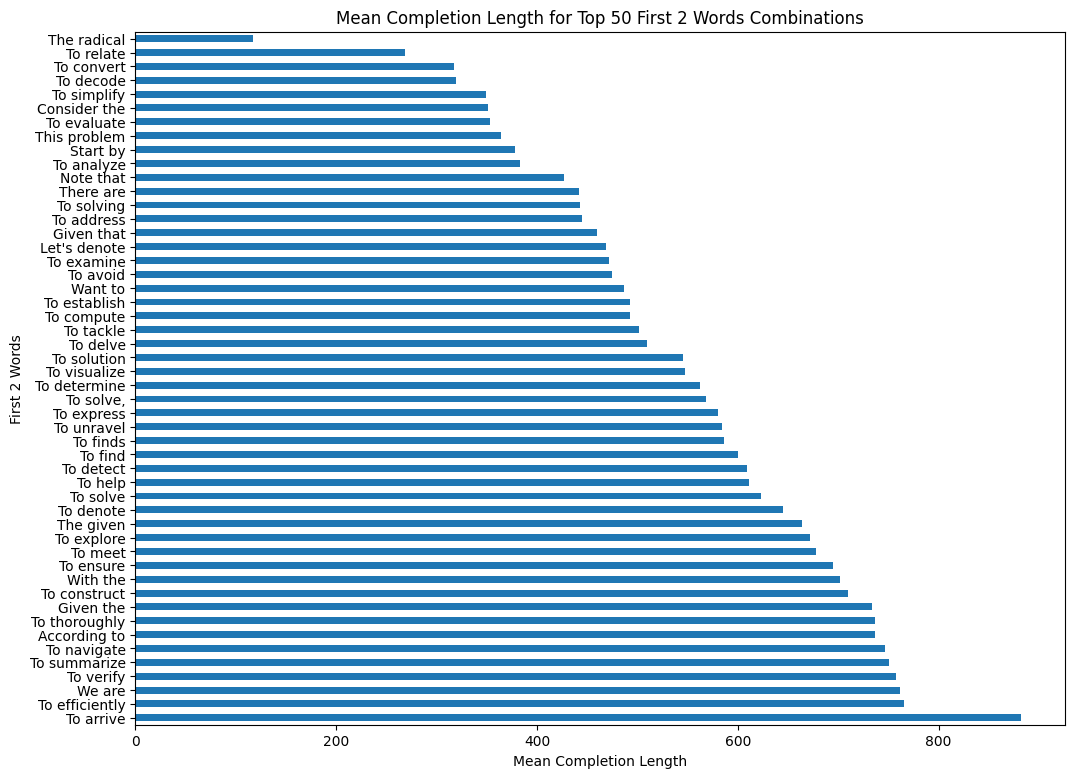

In [112]:
# Calculate the mean completion length for each of the top 30 first 3 words
mean_completion_length = df_samples[df_samples['first_2_words'].isin(top_n_first_2_words)].groupby('first_2_words')['completion_length'].mean()

# Plot the mean completion length for the top 30 first 3 words
plt.figure(figsize=(12, 9))
mean_completion_length.sort_values().plot(kind='barh')
plt.xlabel('Mean Completion Length')
plt.ylabel('First 2 Words')
plt.title(f'Mean Completion Length for Top {top_n} First 2 Words Combinations')
plt.gca().invert_yaxis()
plt.show()

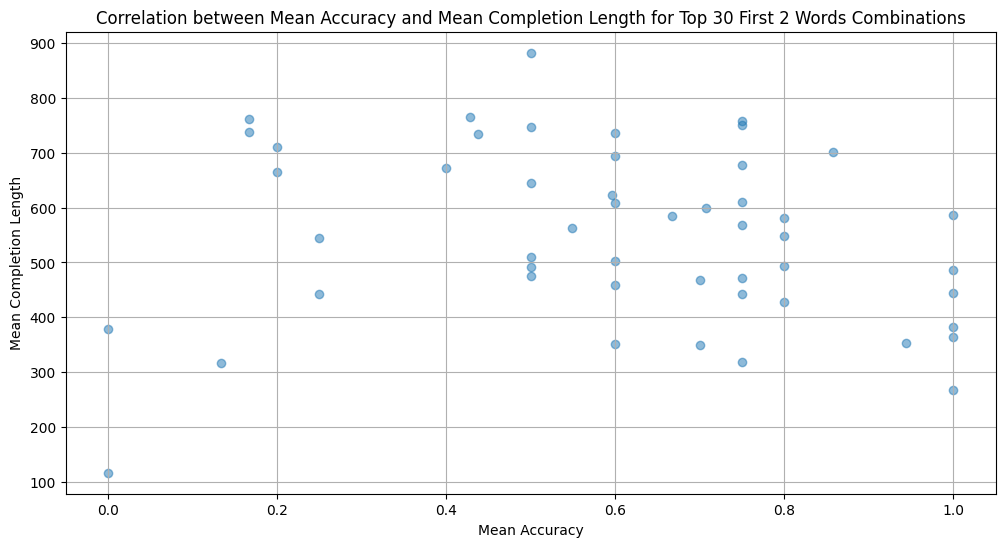

In [113]:
# Scatter plot to show the correlation between mean accuracy and mean completion length for the top 30 first 3 words
plt.figure(figsize=(12, 6))
plt.scatter(mean_accuracy, mean_completion_length, alpha=0.5)
plt.xlabel('Mean Accuracy')
plt.ylabel('Mean Completion Length')
plt.title('Correlation between Mean Accuracy and Mean Completion Length for Top 30 First 2 Words Combinations')
plt.grid(True)
plt.show()